In [1]:
import pandas as pd

# Start from your enriched df
df = pd.read_csv("data/beyondblue_data_flattened_transformers_twitter_english_enriched.csv")
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Keep only posts written by OPs (original + op_reply)
# We can reuse op_map from before:
op_map = df[df['role']=="original"].groupby('parent_post_id')['user_id'].first().to_dict()
df['is_op'] = df.apply(lambda r: r['user_id'] == op_map.get(r['parent_post_id'], None), axis=1)

df_op = df[(df['is_op']) & (df['role'].isin(['original', 'op_reply']))].copy()

# Create a weekly time index
df_op['week'] = df_op['date'].dt.to_period('W').apply(lambda p: p.start_time)

# Aggregate per user per week
op_weekly = (
    df_op
    .groupby(['user_id', 'week'])
    .agg(
        mean_valence=('valence_e', 'mean'),
        mean_arousal=('arousal_e', 'mean'),
        n_posts=('parent_post_id', 'nunique')
    )
    .reset_index()
)

op_weekly.head()

,user_id,week,mean_valence,mean_arousal,n_posts
0,#worriedsick,2024-08-12,0.077496,0.355632,1
1,-Bee,2024-02-12,0.101005,0.789715,1
2,-Bee,2024-03-04,0.522092,0.532322,1
3,-Noah-,2022-06-20,0.323203,0.790971,1
4,-Tayla-,2023-03-20,0.111680,0.536844,1


In [2]:
# Count number of weeks per OP
user_weeks = op_weekly.groupby('user_id')['week'].nunique()
active_users = user_weeks[user_weeks >= 5].index.tolist()   # e.g. >=5 weeks of data

len(active_users), active_users[:5]

(275, ['...Gekota', '21_23', '24yearoldgirl', '41singleBNE', '44Max44'])

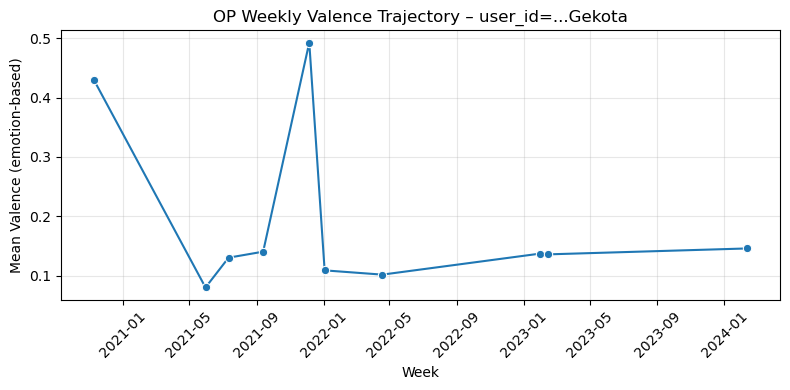

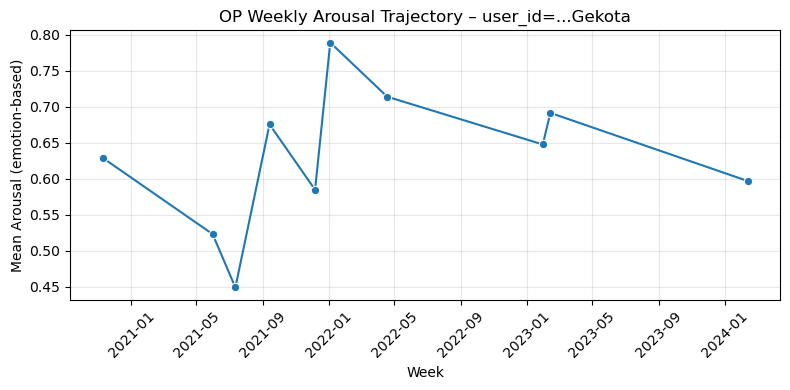

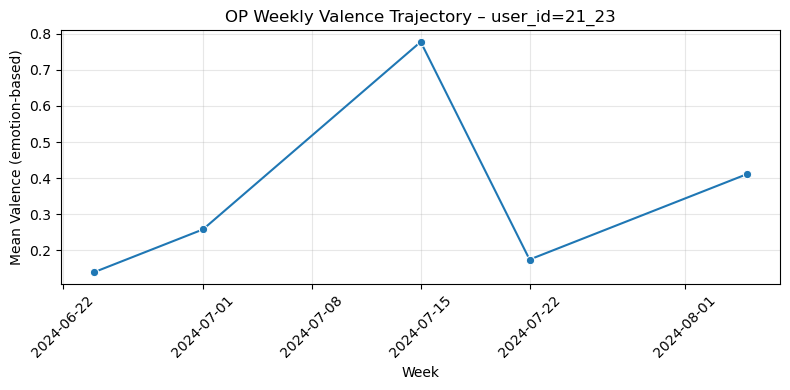

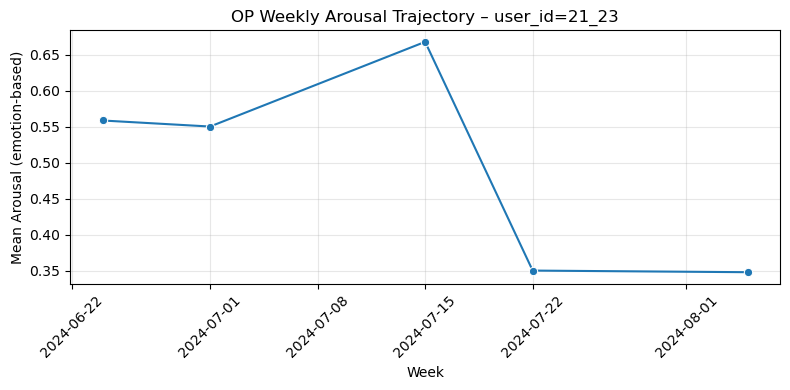

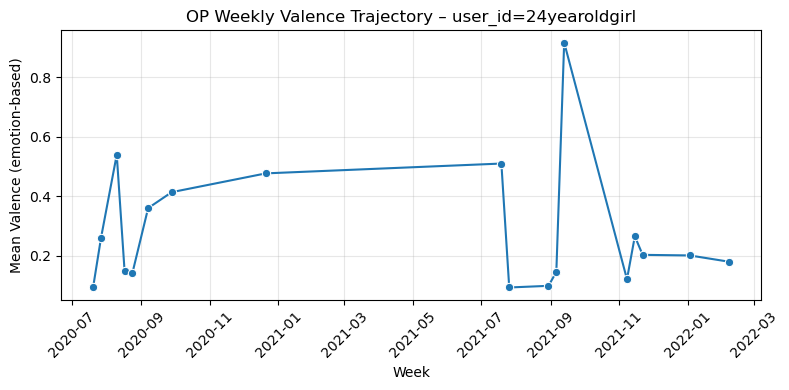

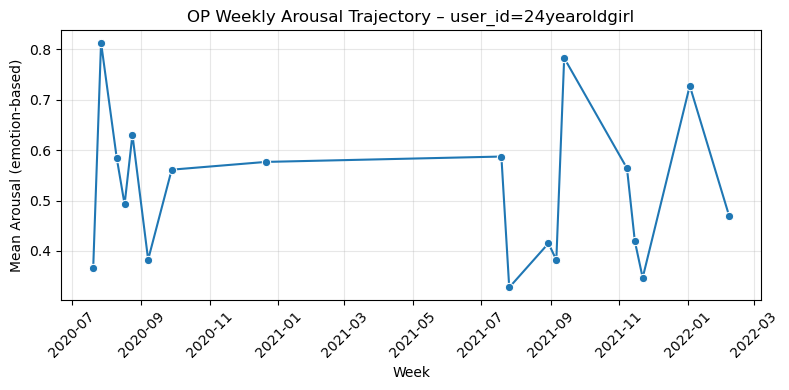

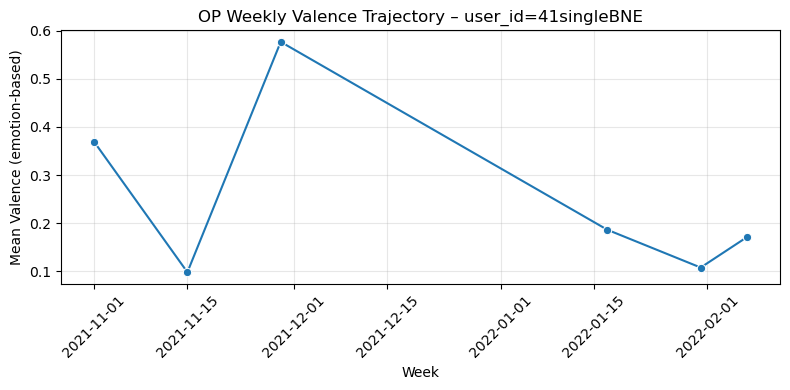

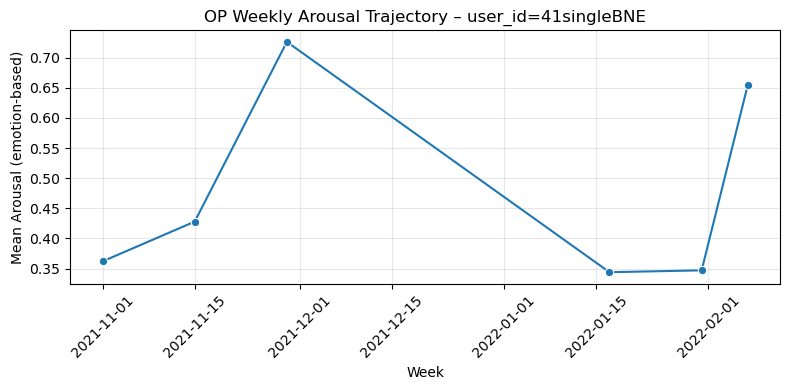

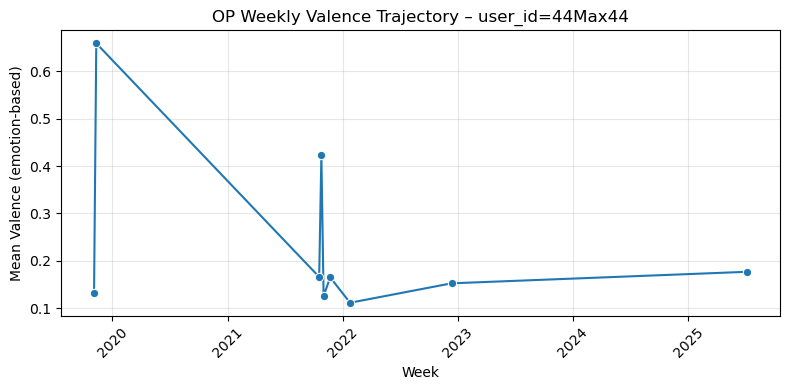

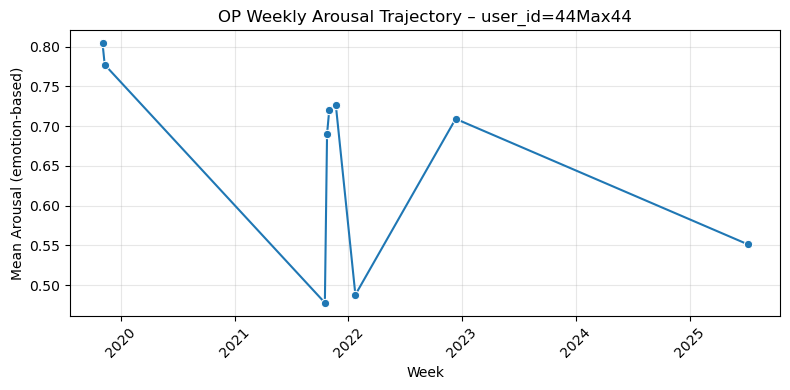

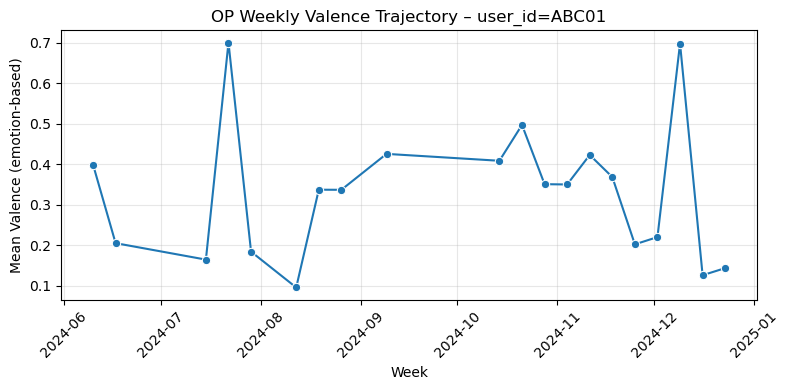

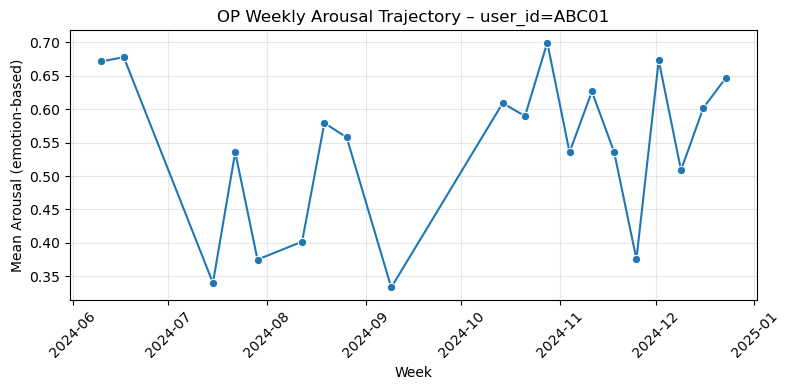

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose a few example active OPs
example_users = active_users[:6]  # first 6 active users

for uid in example_users:
    sub = op_weekly[op_weekly['user_id'] == uid].sort_values('week')

    plt.figure(figsize=(8,4))
    sns.lineplot(data=sub, x='week', y='mean_valence', marker='o')
    plt.title(f"OP Weekly Valence Trajectory – user_id={uid}")
    plt.xlabel("Week")
    plt.ylabel("Mean Valence (emotion-based)")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    sns.lineplot(data=sub, x='week', y='mean_arousal', marker='o')
    plt.title(f"OP Weekly Arousal Trajectory – user_id={uid}")
    plt.xlabel("Week")
    plt.ylabel("Mean Arousal (emotion-based)")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [4]:
# Sort and create per-user lagged valence
op_weekly_sorted = op_weekly.sort_values(['user_id', 'week'])
op_weekly_sorted['valence_lag1'] = op_weekly_sorted.groupby('user_id')['mean_valence'].shift(1)

# Drop first week per user (no lag)
ts_reg = op_weekly_sorted.dropna(subset=['valence_lag1']).copy()

ts_reg[['mean_valence', 'valence_lag1']].head()

,mean_valence,valence_lag1
2,0.522092,0.101005
8,0.079861,0.429115
9,0.130087,0.079861
10,0.140199,0.130087
11,0.492607,0.140199


In [6]:
import statsmodels.api as sm

X = ts_reg['valence_lag1']
y = ts_reg['mean_valence']

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           mean_valence   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     76.18
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           3.75e-18
Time:                        01:54:25   Log-Likelihood:                -114.82
No. Observations:                3953   AIC:                             233.6
Df Residuals:                    3951   BIC:                             246.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.2864      0.006     44.160   